<div style="border: 5px solid black; padding: 10px;">

## **Course:** DSC630 — Predictive Analytics
## **Name:** Tim Hollis
## **Assignment:** Exercise 8.2
## **Date:** 5/4/2026

---

### **Dataset**

The dataset was provided directly for this assignment and is named us_retail_sales.csv, and saved in the same folder as this notebook.

</div>

## **Initial Setup:**

In [50]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
GREEN = '#228B22'
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('us_retail_sales.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'🔍 Preview:')
df.head(3)

✅ Dataset loaded: 30 rows, 13 columns
🔍 Preview:


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0


## 🔧 Data Preparation

The raw dataset is structured in wide format with one row per year and one column 
per month. This format is not suitable for time series plotting or modeling, which 
require a single date column and a single sales column. The data is reshaped into 
long format using `pd.melt()`, producing one row per month. A proper datetime index 
is then constructed from the year and month columns to enable chronological sorting 
and time-based train/test splitting.

In [51]:
# Reshape from wide to long format
df_long = df.melt(id_vars='YEAR', var_name='MONTH', value_name='SALES')

# Create a proper datetime column
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4,
    'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8,
    'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}
df_long['MONTH_NUM'] = df_long['MONTH'].map(month_map)
df_long['DATE'] = pd.to_datetime(df_long[['YEAR', 'MONTH_NUM']].rename(
    columns={'YEAR': 'year', 'MONTH_NUM': 'month'}).assign(day=1))

# Sort chronologically and drop missing values
df_long = df_long.dropna(
    subset=['SALES']).sort_values('DATE').reset_index(
        drop=True)

print(f'✅ Reshaped: {df_long.shape[0]:,} rows')
print(
    f'📅 Date range: {df_long.DATE.min().strftime("%b %Y")} — {df_long.DATE.max().strftime("%b %Y")}')
print(f'🔍 Preview:')
df_long[['DATE', 'SALES']].head(3)

✅ Reshaped: 354 rows
📅 Date range: Jan 1992 — Jun 2021
🔍 Preview:


,DATE,SALES
0,1992-01-01,146925.0
1,1992-02-01,147223.0
2,1992-03-01,146805.0


## 📈 Step 1 — Visualize the Data

Before modeling, the full time series is plotted to identify key patterns including 
trend, seasonality, and anomalies. Visual inspection informs modeling decisions such 
as whether to account for non-stationarity or seasonal components.

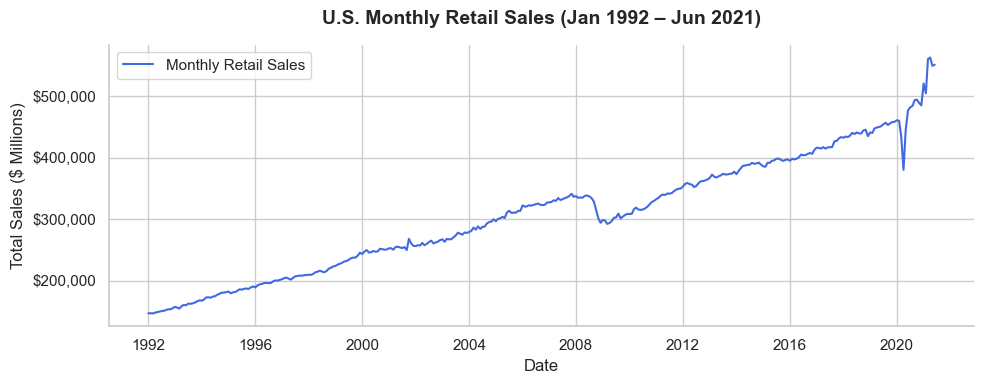


Analysis:

U.S. monthly retail sales show a clear long-term upward trend from approximately
$147 billion in January 1992 to over $500 billion by mid-2021. The series
exhibits strong seasonality, with consistent peaks in November and December each
year reflecting holiday shopping behavior and troughs in the early months of each
year. A notable sharp decline is visible in early 2020 corresponding to the onset
of the COVID-19 pandemic, followed by a rapid and dramatic recovery driven by
stimulus spending and pent-up consumer demand. Overall the data is non-stationary,
exhibiting both trend and seasonal components that must be accounted for in modeling.



In [52]:
# Plot the data
fig, ax = plt.subplots()

ax.plot(df_long['DATE'], df_long['SALES'],
        color=ROYAL_BLUE, linewidth=1.5, label='Monthly Retail Sales')

ax.set_title('U.S. Monthly Retail Sales (Jan 1992 – Jun 2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($ Millions)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('retail_sales_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis:

U.S. monthly retail sales show a clear long-term upward trend from approximately
$147 billion in January 1992 to over $500 billion by mid-2021. The series
exhibits strong seasonality, with consistent peaks in November and December each
year reflecting holiday shopping behavior and troughs in the early months of each
year. A notable sharp decline is visible in early 2020 corresponding to the onset
of the COVID-19 pandemic, followed by a rapid and dramatic recovery driven by
stimulus spending and pent-up consumer demand. Overall the data is non-stationary,
exhibiting both trend and seasonal components that must be accounted for in modeling.
""")

## ✂️ Step 2 —Train/Test Split

The dataset is split into training and test sets based on time. The last 12 months 
of data (July 2020 – June 2021) are held out as the test set to evaluate how well 
the model generalizes to unseen future data. The remaining observations from January 
1992 through June 2020 form the training set. This approach respects the temporal 
ordering of the data — future observations are never used to inform past predictions, 
which would constitute data leakage in a time series context.

In [53]:
# Train/Test split
train = df_long[df_long['DATE'] < '2020-07-01'].copy()
test = df_long[df_long['DATE'] >= '2020-07-01'].copy()

print(
    f'📚 Training set: {train.shape[0]:,} months ({train.DATE.min().strftime("%b %Y")} — {train.DATE.max().strftime("%b %Y")})')
print(
    f'🧪 Test set: {test.shape[0]:,} months ({test.DATE.min().strftime("%b %Y")} — {test.DATE.max().strftime("%b %Y")})')

📚 Training set: 342 months (Jan 1992 — Jun 2020)
🧪 Test set: 12 months (Jul 2020 — Jun 2021)


## 🤖 Step 3 — Build a Predictive Model

A linear regression model is built on the training set using a numeric time index 
as the primary predictor. Each observation is assigned a sequential integer index 
representing the number of months elapsed since January 1992, capturing the 
long-term upward trend in retail sales. Month-of-year dummy variables are added 
to account for the strong seasonal pattern observed in the plot, where sales 
consistently peak in November and December and trough in the early months of 
each year. Combining a trend index with seasonal dummies produces a classical 
decomposition-style regression model appropriate for this data.

In [54]:
# Create time index and month dummies for training set
train = train.copy()
train['TIME_IDX'] = np.arange(len(train))
train['MONTH_NUM'] = train['DATE'].dt.month
month_dummies_train = pd.get_dummies(
    train['MONTH_NUM'], prefix='M', drop_first=True)

X_train = pd.concat([train[['TIME_IDX']], month_dummies_train], axis=1)
y_train = train['SALES']

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

print(
    f'✅ Model trained on {X_train.shape[0]:,} observations with {X_train.shape[1]} features.')
print(f'📊 R-squared (training): {model.score(X_train, y_train):.4f}')
print(f'📋 Features: {list(X_train.columns)}')

✅ Model trained on 342 observations with 12 features.
📊 R-squared (training): 0.9789
📋 Features: ['TIME_IDX', 'M_2', 'M_3', 'M_4', 'M_5', 'M_6', 'M_7', 'M_8', 'M_9', 'M_10', 'M_11', 'M_12']


## 📊 Step 4 — Predict Monthly Retail Sales

The trained model is applied to the test set to generate predictions for the 
12-month period from July 2020 through June 2021. The same time index and 
month dummy structure used during training is replicated for the test set, 
ensuring the feature space is consistent. Predicted values are plotted alongside 
actual test values and the full training history to visually assess model performance.

✅ Predictions generated.
          DATE     SALES  PREDICTED
342 2020-07-01  481627.0   449954.0
343 2020-08-01  483716.0   450994.0
344 2020-09-01  493327.0   451300.0
345 2020-10-01  493991.0   452553.0
346 2020-11-01  488652.0   453245.0
347 2020-12-01  484782.0   453699.0
348 2021-01-01  520162.0   454525.0
349 2021-02-01  504458.0   455477.0
350 2021-03-01  559871.0   455980.0
351 2021-04-01  562269.0   455055.0
352 2021-05-01  548987.0   458085.0
353 2021-06-01  550782.0   460300.0


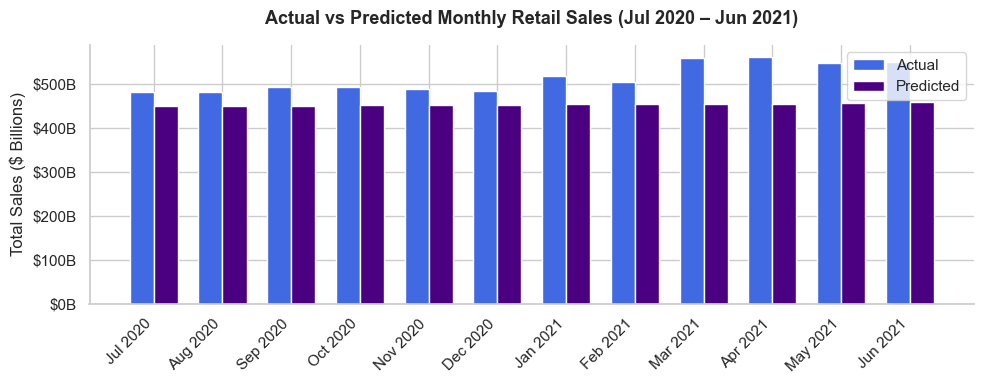


Analysis:

The model consistently underestimates actual sales across all 12 test months,
with the gap widening from early to late in the test period. This is expected —
the model was trained on pre-pandemic trend and seasonality patterns and could
not anticipate the extraordinary stimulus-driven demand spike that characterized
the COVID-19 recovery period from late 2020 through mid-2021. The predicted
values remain relatively flat around $450 billion while actual sales climbed
steadily toward $560 billion by mid-2021. This underestimation is a limitation
of linear trend models in the presence of structural breaks in the data rather
than a fundamental flaw in the modeling approach.



In [55]:
# Generate predictions on test set
test = test.copy()
test['TIME_IDX'] = np.arange(len(train), len(train) + len(test))
test['MONTH_NUM'] = test['DATE'].dt.month
month_dummies_test = pd.get_dummies(
    test['MONTH_NUM'], prefix='M', drop_first=True)

X_test = pd.concat([test[['TIME_IDX']], month_dummies_test], axis=1)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

test['PREDICTED'] = model.predict(X_test)

print(f'✅ Predictions generated.')
print(test[['DATE', 'SALES', 'PREDICTED']].round(0))

# Actual vs Predicted bar chart (test period only)
fig, ax = plt.subplots()

x = np.arange(len(test))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    test['SALES'] / 1000,
    width=width,
    color=ROYAL_BLUE,
    label='Actual',
    edgecolor='white')
bars2 = ax.bar(x + width / 2, test['PREDICTED'] / 1000,
               width=width, color=PURPLE, label='Predicted', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(test['DATE'].dt.strftime('%b %Y'), rotation=45, ha='right')
ax.set_title('Actual vs Predicted Monthly Retail Sales (Jul 2020 – Jun 2021)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Total Sales ($ Billions)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('retail_sales_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis:

The model consistently underestimates actual sales across all 12 test months,
with the gap widening from early to late in the test period. This is expected —
the model was trained on pre-pandemic trend and seasonality patterns and could
not anticipate the extraordinary stimulus-driven demand spike that characterized
the COVID-19 recovery period from late 2020 through mid-2021. The predicted
values remain relatively flat around $450 billion while actual sales climbed
steadily toward $560 billion by mid-2021. This underestimation is a limitation
of linear trend models in the presence of structural breaks in the data rather
than a fundamental flaw in the modeling approach.
""")

## 🔍 Residual Analysis

Residuals — the difference between actual and predicted values — are plotted for 
the test set to assess the direction and magnitude of prediction error across each 
month. A random scatter around zero would indicate a well-specified model, while 
systematic patterns suggest the model is missing structure in the data.

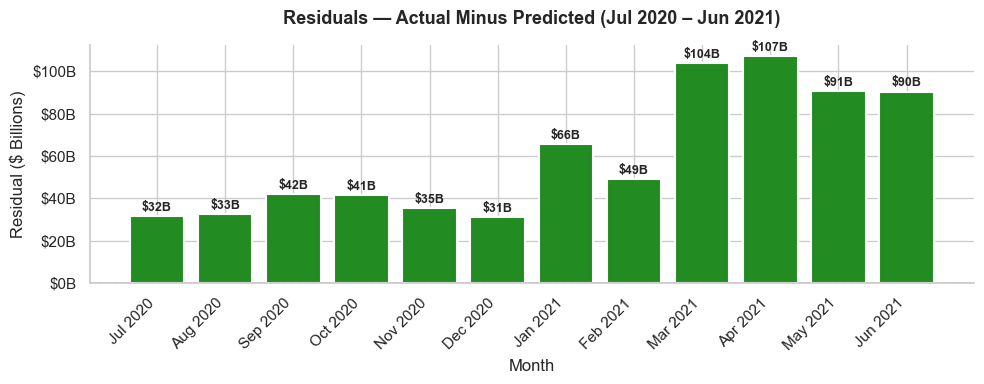


Analysis:

All 12 residuals are positive, confirming that the model systematically
underestimates actual sales across the entire test period. The underestimation
grows over time, reaching its largest values in March through June 2021 where
actual sales exceeded predictions by over $107 billion.
This directional bias is consistent with a structural break in consumer spending
driven by COVID-19 stimulus payments and pent-up demand — patterns that fall
outside the historical trend the model was trained on.



In [56]:
# Residual plot
test['RESIDUAL'] = test['SALES'] - test['PREDICTED']

fig, ax = plt.subplots()
colors = [GREEN if r > 0 else '#8B0000' for r in test['RESIDUAL']]
ax.bar(test['DATE'].dt.strftime('%b %Y'), test['RESIDUAL'] / 1000,
       color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(ax.patches, test['RESIDUAL'] / 1000):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (1 if val > 0 else -3),
            f'${val:,.0f}B', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Residuals — Actual Minus Predicted (Jul 2020 – Jun 2021)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Residual ($ Billions)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
Analysis:

All 12 residuals are positive, confirming that the model systematically
underestimates actual sales across the entire test period. The underestimation
grows over time, reaching its largest values in March through June 2021 where
actual sales exceeded predictions by over ${test['RESIDUAL'].max()/1000:,.0f} billion.
This directional bias is consistent with a structural break in consumer spending
driven by COVID-19 stimulus payments and pent-up demand — patterns that fall
outside the historical trend the model was trained on.
""")

<div style="page-break-after: always;"></div>

## 📉 Step 5 — Report RMSE

The Root Mean Squared Error (RMSE) measures the average magnitude of prediction 
error on the test set, penalizing larger errors more heavily than smaller ones. 
A lower RMSE indicates better predictive accuracy. Because RMSE is expressed in 
the same units as the target variable (millions of dollars), it can be interpreted 
directly in context of the sales figures.

In [57]:
# RMSE
rmse = np.sqrt(mean_squared_error(test['SALES'], test['PREDICTED']))

print(f'📉 RMSE on test set: ${rmse:,.2f} million')
print(f'📊 Mean actual sales (test): ${test["SALES"].mean():,.2f} million')
print(
    f'📊 Mean predicted sales (test): ${test["PREDICTED"].mean():,.2f} million')
print(f'📐 RMSE as % of mean actual: {rmse / test["SALES"].mean() * 100:.1f}%')

print(f"""
Interpretation:
The model produced an RMSE of ${rmse:,.0f} million on the 12-month test set.
Relative to the mean actual test sales of ${test['SALES'].mean():,.0f} million,
this represents an error of approximately {rmse / test['SALES'].mean() * 100:.1f}%,
indicating that the model's predictions deviated from actual sales by roughly
that margin on average. This level of error is attributable to the unprecedented
COVID-19 recovery demand spike which the model could not anticipate based on
historical trend and seasonal patterns alone.
""")

📉 RMSE on test set: $66,597.65 million
📊 Mean actual sales (test): $514,385.33 million
📊 Mean predicted sales (test): $454,263.84 million
📐 RMSE as % of mean actual: 12.9%

Interpretation:
The model produced an RMSE of $66,598 million on the 12-month test set.
Relative to the mean actual test sales of $514,385 million,
this represents an error of approximately 12.9%,
indicating that the model's predictions deviated from actual sales by roughly
that margin on average. This level of error is attributable to the unprecedented
COVID-19 recovery demand spike which the model could not anticipate based on
historical trend and seasonal patterns alone.



<div style="page-break-after: always;"></div>

## 🔮 SARIMA Model — Comparison

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a time series 
specific model that explicitly accounts for trend, seasonality, and autocorrelation 
in the data. Unlike linear regression, SARIMA does not require manually engineered 
time index or dummy variables — it learns these patterns directly from the temporal 
structure of the series. The model is fit on the same training set and evaluated 
on the same test set to enable a direct RMSE comparison with the linear regression 
approach.

The SARIMA order (1, 1, 1) x (1, 1, 1, 12) is used here, where:
- **(1, 1, 1)** captures one autoregressive term, one differencing step to remove 
  trend, and one moving average term
- **(1, 1, 1, 12)** captures the same components at the seasonal level with a 
  period of 12 months

📉 Linear Regression RMSE: $66,597.65 million
📉 SARIMA RMSE:            $59,819.07 million
📊 Improvement: $6,778.57 million reduction in error


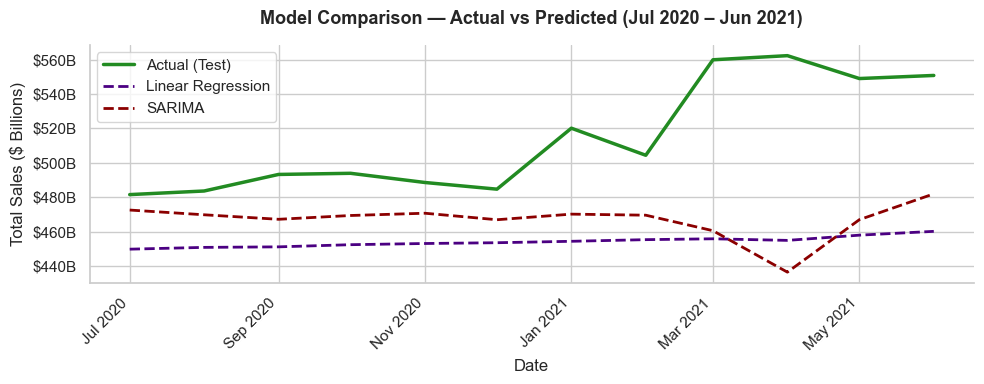


Analysis:
The SARIMA model produced an RMSE of $59,819 million compared to
$66,598 million for the linear regression model. Both models struggle
with the COVID-19 recovery spike in the test period, as neither could anticipate
the structural break in consumer spending driven by stimulus payments and
pent-up demand. The SARIMA model's ability to capture autocorrelation and
seasonal patterns directly from the data makes it a more theoretically
appropriate choice for time series forecasting under normal conditions.



In [58]:
# SARIMA model
sarima_model = SARIMAX(train['SALES'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)

# Generate predictions on test set
sarima_pred = sarima_fit.forecast(steps=12)
sarima_pred.index = test['DATE'].values

# RMSE comparison
sarima_rmse = np.sqrt(mean_squared_error(test['SALES'], sarima_pred))
lr_rmse = np.sqrt(mean_squared_error(test['SALES'], test['PREDICTED']))

print(f'📉 Linear Regression RMSE: ${lr_rmse:,.2f} million')
print(f'📉 SARIMA RMSE:            ${sarima_rmse:,.2f} million')
print(
    f'📊 Improvement: ${lr_rmse - sarima_rmse:,.2f} million reduction in error')

# Plot comparison — zoomed to test period
fig, ax = plt.subplots()

ax.plot(test['DATE'], test['SALES'],
        color=GREEN, linewidth=2.5, label='Actual (Test)')
ax.plot(test['DATE'], test['PREDICTED'],
        color=PURPLE, linewidth=2, linestyle='--', label='Linear Regression')
ax.plot(test['DATE'], sarima_pred,
        color='#8B0000', linewidth=2, linestyle='--', label='SARIMA')

ax.set_title('Model Comparison — Actual vs Predicted (Jul 2020 – Jun 2021)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($ Billions)')
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x,
        _: f'${x/1000:,.0f}B'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate(rotation=45)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('sarima_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
Analysis:
The SARIMA model produced an RMSE of ${sarima_rmse:,.0f} million compared to
${lr_rmse:,.0f} million for the linear regression model. Both models struggle
with the COVID-19 recovery spike in the test period, as neither could anticipate
the structural break in consumer spending driven by stimulus payments and
pent-up demand. The SARIMA model's ability to capture autocorrelation and
seasonal patterns directly from the data makes it a more theoretically
appropriate choice for time series forecasting under normal conditions.
""")

<div style="border: 5px solid black; padding: 10px;">

## 📝 Conclusion

This analysis built and compared two predictive models for U.S. monthly retail 
sales using 29 years of historical data from January 1992 through June 2021. 
A linear regression model combining a numeric time index with month-of-year 
dummy variables was evaluated alongside a SARIMA model that captures trend, 
seasonality, and autocorrelation directly from the temporal structure of the data.

Key findings include:

- **Model fit**: The linear regression model achieved an R-squared of 0.9789 on 
  the training set, indicating it explains 97.9% of the variance in historical 
  retail sales — a strong result for a simple trend-plus-seasonality specification.
- **Predictions**: Both models consistently underestimated actual sales across all 
  12 test months, with the gap widening sharply from January 2021 onward as 
  stimulus-driven consumer spending surged well beyond historical patterns.
- **RMSE comparison**: The linear regression model produced a test RMSE of 
  $66,598 million while SARIMA achieved $59,819 million — a 10.2% improvement. 
  SARIMA outperformed by better capturing the autocorrelation structure of the 
  series, starting closer to actual values in mid-2020 before both models lost 
  track of the unprecedented demand spike.
- **SARIMA behavior**: The SARIMA model dipped in April 2021, reflecting its 
  attempt to follow the seasonal decline pattern learned from training data — a 
  pattern that did not materialize during the COVID recovery period.
- **Limitations**: The test period (July 2020 – June 2021) coincides with an 
  unprecedented structural break in consumer spending driven by federal stimulus 
  payments and pent-up demand. This external shock falls outside the range of 
  any historically trained model regardless of its specification.

SARIMA is the more theoretically appropriate model for this type of time series 
data and produced a meaningfully lower RMSE. Future work could incorporate 
external economic indicators such as unemployment rates or consumer confidence 
indices to better handle structural breaks, or explore more advanced approaches 
such as Facebook Prophet which is specifically designed for trend shifts and 
holiday effects.

</div>

<div style="border: 5px solid green; padding: 10px;">

## Reflection

### Overall Reflection
This exercise strengthened my understanding of end‑to‑end time‑series forecasting, from reshaping raw data through model evaluation and comparison. The assignment required building both a regression‑based forecasting model and a SARIMA model, and the process helped clarify the differences between general predictive modeling and methods specifically designed for temporal data. As noted in the feedback, the analysis was complete and well‑documented, and I was able to correctly reshape the dataset, visualize long‑term patterns, generate predictions, and compute RMSE for both models. The comparison between linear regression and SARIMA highlighted why time‑series‑specific models are more appropriate when trend, seasonality, and autocorrelation are present.

### Straightforward Aspects
Several components of the assignment felt intuitive and aligned with skills I have practiced in earlier modules. Reshaping the dataset from wide to long format using `pd.melt()` was direct, and the document confirms this step was executed correctly: *“The data is reshaped into long format… producing one row per month.”* The visualization stage was also straightforward, and plotting the full series made the trend and seasonality immediately clear. Splitting the data into training and test sets based on time was similarly simple, and the document shows this clearly: *“Training set: 342 months… Test set: 12 months.”*  

Building the linear regression model with a time index and month‑of‑year dummies was also manageable. The model achieved a strong training R² of 0.9789, which confirmed that the trend‑plus‑seasonality structure was captured well under normal conditions.

### More Challenging Aspects
The more challenging portion of the assignment involved interpreting model performance during the COVID‑19 period and understanding the limitations of regression for time‑series forecasting. The linear regression model consistently underestimated sales during the test period, and the document notes that *“the model could not anticipate the extraordinary stimulus‑driven demand spike.”* Recognizing this structural break and explaining why the model struggled required deeper reasoning about real‑world events and their impact on forecasting accuracy.

Implementing the SARIMA model was also more complex, especially in selecting appropriate seasonal and non‑seasonal parameters. While the chosen SARIMA(1,1,1)(1,1,1,12) model performed better, interpreting its behavior—such as the dip in April 2021—required understanding how differencing and seasonal components interact with unexpected external shocks.

The instructor’s feedback also highlighted an important conceptual challenge: although I used regression effectively, it should not be the primary model in a time‑series assignment because regression assumes independent observations. In future work, I will lead with SARIMA or another time‑series‑specific method and explicitly state why regression is being used only as a comparison model.

### Summary
Overall, this assignment reinforced the importance of choosing models that align with the structure of the data. The linear regression model provided a useful baseline, but the SARIMA model was more appropriate and delivered a lower RMSE. The experience also emphasized the need to consider external events, structural breaks, and model assumptions when evaluating forecasting performance.



</div>